# ArXiv Bayesian Classification Assignment

# 1. Environment Setup & Data Loading
The students need the ArXiv dataset from Kaggle. We use a subset to keep the computation manageable.

In [99]:
# pip install kagglehub pandas numpy matplotlib scikit-learn tqdm

# Standard Library Imports
import os
import json
import shutil

# Third-Party Library Imports
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

# Scikit-Learn Utilities
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import classification_report, hamming_loss

# --- CONFIGURATION ---
DATASET_PATH = "./data/arxiv-metadata-oai-snapshot.json"
LIMIT = 100000

In [100]:
# Create the local directory if it doesn't exist
os.makedirs(os.path.dirname(DATASET_PATH), exist_ok=True)

# 1. Check if the file exists; if not, download it
if not os.path.exists(DATASET_PATH):
    print("🚀 Downloading dataset...")
    # download_path returns the folder containing the file
    download_path = kagglehub.dataset_download("Cornell-University/arxiv")
    
    # Locate the metadata file in the downloaded folder
    downloaded_json = os.path.join(download_path, "arxiv-metadata-oai-snapshot.json")
    
    # Use shutil.move instead of os.replace to handle cross-drive transfers
    print("🚚 Moving dataset to local directory (this may take a moment on Windows)...")
    shutil.move(downloaded_json, DATASET_PATH)
    print(f"✅ Dataset saved to: {DATASET_PATH}")
else:
    print(f"📦 Dataset already exists at: {DATASET_PATH}")

# Assign to your specific variable for the rest of the script
json_path = DATASET_PATH

📦 Dataset already exists at: ./data/arxiv-metadata-oai-snapshot.json


Successfully loaded 100000 high-quality samples.


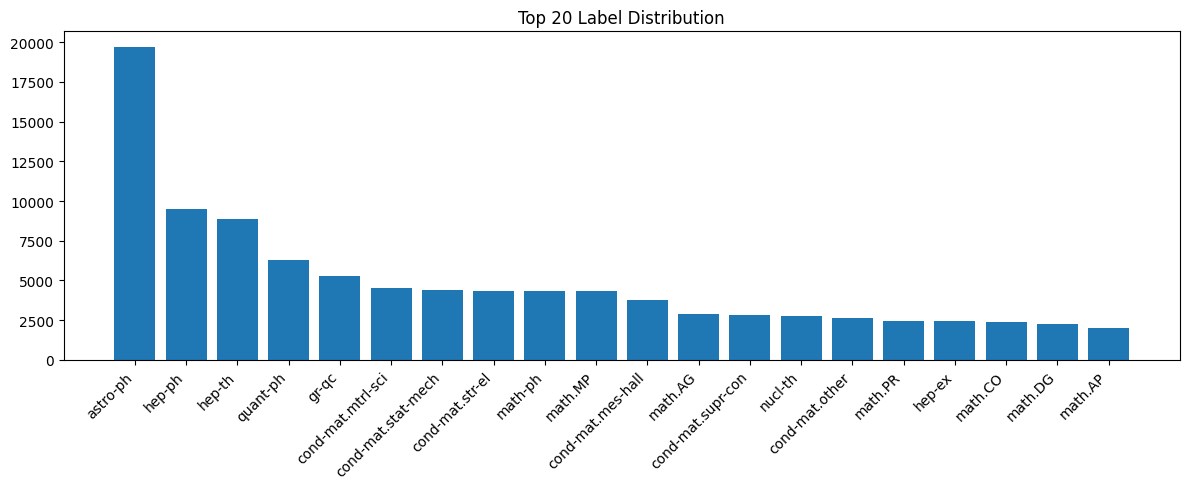

In [101]:

def load_clean_data(path, limit):
    texts, labels = [], []
    count = 0
    
    with open(path, 'r') as f:
        for line in f:
            if count >= limit:
                break
            
            paper = json.loads(line)
            
            # TODO 1: Data Quality Filter
            # Arxiv data can be messy. Implement a check to ensure:
            # 1. 'title' and 'abstract' are not empty strings.
            # 2. The 'categories' field is not None.
            # If the data is "bad", skip this iteration using 'continue'.
            if paper['title'] ==  "" or paper['abstract'] == "" or paper['categories'] == None:
                continue


            # TODO 1.2: Text Harmonization
            # Combine Title and Abstract. 
            # Remove common Arxiv artifacts like "Comments: X pages" 
            # or version numbers (v1, v2) if they appear in the text.
            import re
            text = paper['title'] + " " + paper['abstract']
            text = re.sub(r'\bv\d+\b', '', text)
            text = re.sub(r'Comments:.*', '', text)
            texts.append(text.strip())
            labels.append(paper['categories'].split())
            count += 1
            
    return texts, labels

X_raw, y_raw = load_clean_data(json_path, LIMIT)
print(f"Successfully loaded {len(X_raw)} high-quality samples.")

# --- TODO 2: Label Filtering ---
# With 100000 papers, you might have hundreds of unique categories. 
# Some might only appear once. Consider filtering out categories that 
# appear in fewer than, say, 50 papers to improve model stability.

from collections import Counter
all_cats = [cat for cats in y_raw for cat in cats] # all categories
cat_counts = Counter(all_cats) # Dictionary pair of category : count
valid_cats = {cat for cat, count in cat_counts.items() if count >= 50} # Remove categories that appear less than 50 times

filtered = [(text, [cat for cat in cats if cat in valid_cats]) for text, cats in zip(X_raw, y_raw)] # Creates new array with filtered categories
filtered = [(text, cats) for text, cats in filtered if cats] # Removes entries with empty categories

X_raw, y_raw = zip(*filtered) # Variables now contain filtered data
X_raw, y_raw = list(X_raw), list(y_raw) # Ensure 'list' type

# Multi-label binarization: Converts lists of categories into a binary matrix.
# Example: If classes are ['cs.AI', 'cs.CV', 'cs.LG'], then:
# ['cs.AI', 'cs.LG'] becomes [1, 0, 1]
mlb = MultiLabelBinarizer()
y = mlb.fit_transform(y_raw)

# Split the data
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_raw, y, test_size=0.2, random_state=42)

# TODO 3: Vectorize the text data.
# Convert X_train_raw and X_test_raw into numerical format using CountVectorizer.
# Remember: fit on train, transform on both.


# TODO 4 (Free Response - Report): Class Imbalance Check
# Multi-label datasets are often heavily skewed. 
# Plot the distribution of the top 20 labels to see if the model 
# will be biased toward 'cs.CV' or 'math.CO' etc.
label_counts = y.sum(axis=0)
top20_idx = np.argsort(label_counts)[::-1][:20]
top20_labels = mlb.classes_[top20_idx]
top20_counts = np.asarray(label_counts[top20_idx]).flatten()

plt.figure(figsize=(12,5))
plt.bar(top20_labels, top20_counts)
plt.xticks(rotation=45, ha='right')
plt.title('Top 20 Label Distribution')
plt.tight_layout()
plt.show()

# 2. Feature Engineering: The "Evidence"

In [102]:
# TODO 5 (Free Response - Report): Vocabulary Analysis
# After fitting the vectorizer, print the first 20 words in the vocabulary.
# Do these words look helpful for classification, or are they "noise"?


# --- TODO 6: Addressing Memory Efficiency ---
# We are currently using .toarray() which converts sparse matrices to dense.
# With 100000 papers, this might cause a MemoryError (RAM crash).
# TODO: Try removing .toarray() and see if the Scikit-learn model still works.

# --- TODO 7: N-grams ---
# Currently, we look at single words ("intelligence"). 
# TODO: Change the vectorizer to include bigrams (pairs of words) like "artificial intelligence".


# We use CountVectorizer to create the Bag-of-Words matrix
# Instructor Note: Encourage students to experiment with min_df and max_df 
# to see how it affects the Bayesian Prior.
vectorizer = CountVectorizer(stop_words='english', max_features=5000, ngram_range=(1, 2))
X_train = vectorizer.fit_transform(X_train_raw)
X_test = vectorizer.transform(X_test_raw)

print(f"Vocabulary Size: {len(vectorizer.vocabulary_)}")
print(vectorizer.get_feature_names_out()[100:120])

Vocabulary Size: 5000
['75' '80' '85' '87' '90' '95' '96' '96 tev' '98' '980' '99' '_1' '_2'
 '_3' '_4' '_n' '_x' 'a_' 'a_1' 'a_n']


In [103]:
print(X_train.shape)
print(X_train[:3, :100].toarray())

(79968, 5000)
[[0 0 0 0 0 0 0 0 0 0 0 3 0 0 0 2 0 0 6 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 4
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]


In [104]:
print(y_train.shape)
print(y_train[:3, :10])

(79968, 126)
[[1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 1 0]
 [0 0 1 0 0 0 0 0 0 0]]


# 3. [STUDENT TASK] Implementing the Bayesian Core
This is where the heavy lifting happens. Instead of using sklearn, students must implement the math

In [105]:
class AdvancedBayesianClassifier:
    def __init__(self, alpha=1.0):
        self.alpha = alpha  # Laplace Smoothing parameter
        self.priors = None
        self.feature_probs = None
        self.classes = None
        self.threshold = None
        self.class_binary = None

    def fit(self, X, y):
        """
        STUDENT TODO 8: Implement the training phase.
        1. Calculate the Prior Probability of each class P(C).
        2. Calculate the Likelihood P(Word|Class) using Laplace Smoothing.
        3. Store these in log-space to prevent numerical underflow.
        """
        n_samples, n_features = X.shape
        n_classes = y.shape[1]
        
        # Calculate log-priors: log(count(c) / total)
        self.priors = np.log(y.sum(axis=0) / n_samples)
        # Calculate log-likelihoods with Laplace Smoothing
        # P(w|c) = (count(w in c) + alpha) / (total_words_in_c + alpha * n_features)
        self.feature_probs = np.log((y.T @ X + self.alpha)/(((y.T @ X).sum(axis=1).reshape(-1, 1)) + self.alpha * n_features))
        
        # TODO 4: In the fit() method, remember that y is a binary matrix.
        # How do you get the total count of documents for class 'c'?
        # Hint: axis=0 is your friend.
        
        pass

    

    def predict(self, X):
        """
        STUDENT TODO 9: Implement the inference phase.
        For each document, calculate: log P(C) + sum(log P(Word|C))
        Return a binary matrix (n_samples, n_classes).
        """
        # Compute scores for all classes: Log-Prior + (X dot Log-Likelihoods.T)
        self.classes = self.priors + (X @ self.feature_probs.T)
        self.threshold = np.percentile(self.classes, 95, axis=1).reshape(-1,1)
        self.classes_binary = np.where(self.classes > self.threshold, 1, 0)
        # TODO: Thresholding.
        # Multi-label is tricky. Unlike multi-class (where you take the max), 
        # here a document can belong to many classes. Decide on a rule 
        # (e.g., score > threshold) to mark a label as 1
        # Use 95%.   


        return  self.classes_binary
# Initialize and train
model = AdvancedBayesianClassifier(alpha=1.0)
model.fit(X_train, y_train)

In [106]:
model.predict(X_train)

array([[1, 0, 0, ..., 0, 0, 0],
       [0, 1, 1, ..., 0, 0, 0],
       [0, 1, 1, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(79968, 126))

In [107]:
model.predict(X_train)
print(model.feature_probs.shape)
print(model.feature_probs[:10][:10])

print(model.threshold)
print(model.classes[:10][:10])
print(model.classes_binary[:10][:10])



(126, 5000)
[[ -8.44458592 -10.21602539  -8.56935813 ... -14.2764684  -10.84248119
   -8.20804281]
 [-11.36508649  -9.97879213  -9.75564858 ...  -9.57332702  -9.57332702
   -9.28564495]
 [ -9.5871865   -8.8612495   -9.81033005 ...  -7.69006652 -10.34932655
   -8.8612495 ]
 ...
 [-10.71316884  -8.81604886  -9.36943409 ...  -9.03919241  -8.0860877
   -8.61310801]
 [-10.95735233  -9.97652307 -10.11005447 ...  -9.49101526  -8.14394161
   -8.47244568]
 [-10.12506989 -10.12506989 -10.12506989 ... -10.12506989 -10.12506989
  -10.12506989]]
[[-1118.9739896 ]
 [ -475.14444759]
 [ -229.9709701 ]
 ...
 [ -136.04592939]
 [ -281.55723369]
 [ -240.37365394]]
[[ -999.59947959 -1219.50513433 -1252.5859846  ... -1201.90283726
  -1176.53673431 -1242.36052432]
 [ -530.31055221  -471.12923725  -465.56194271 ...  -540.29592362
   -528.17775506  -558.63179835]
 [ -257.96450972  -229.96420766  -222.42756878 ...  -258.24437837
   -253.6022655   -271.39485367]
 ...
 [ -366.33558663  -323.46618531  -333.3373962

# 4. Evaluation & Analysis
Students must go beyond accuracy. In multi-label ArXiv data, Hamming Loss and F1-Score are vital.

In [108]:
y_pred = model.predict(X_test)
np.random.seed(42)                                                                                     
sample_indices = np.random.choice(len(X_test_raw), 3, replace=False) 
for idx in sample_indices:
      print(f"--- Paper {idx} ---")                                                                      
      print(f"Text: {X_test_raw[idx][:200]}...")                                                         
      print(f"True labels:      {mlb.classes_[y_test[idx] == 1]}")
      print(f"Predicted labels: {mlb.classes_[y_pred[idx] == 1]}")                                       
      print()     
# TODO 10 (Free Response - Report): Hamming Loss Interpretation
# In your own words, explain why a low Hamming Loss doesn't necessarily 
# mean the model is "good" for a highly imbalanced dataset like arXiv.


# TODO 11 (Analysis - Report): Qualitative Analysis
# Pick 3 random papers from the test set. Print their Title/Abstract, 
# the Ground Truth labels, and the labels your Model predicted. 
# Does the model "fail gracefully"?

print("Hamming Loss:", hamming_loss(y_test, y_pred))

# TODO 12 (Free Response - Report): Macro vs. Micro Averaging
# Look at the classification report. Why is there a big difference 
# between 'macro avg' and 'weighted avg'? 
# Hint: Look at the 'support' column.

# Use zero_division to handle classes with no predictions
print(classification_report(y_test, y_pred, target_names=mlb.classes_, zero_division=0))

--- Paper 19666 ---
Text: Automating Renormalization of Quantum Field Theories   We give an overview of state-of-the-art multi-loop Feynman diagram
computations, and explain how we use symbolic manipulation to generate
renorma...
True labels:      ['hep-ph']
Predicted labels: ['cs.HC' 'cs.PL' 'cs.SE' 'hep-lat' 'hep-th' 'math-ph' 'math.MP']

--- Paper 6463 ---
Text: On the Gromov hyperbolicity of the Kobayashi metric on strictly
  pseudoconvex regions in the almost complex case   We prove that every bounded strictly $J$-convex region equipped with the
Kobayashi m...
True labels:      ['math.CV' 'math.DG']
Predicted labels: ['math.CV' 'math.DG' 'math.DS' 'math.FA' 'math.GT' 'math.MG' 'math.SG']

--- Paper 1815 ---
Text: Capillary-Driven Instability of Immiscible Fluid Interfaces Flowing in
  Parallel in Porous Media   When immiscible wetting and non-wetting fluids move in parallel in a porous
medium, an instability m...
True labels:      ['cond-mat.dis-nn']
Predicted labels: ['cond-mat.s

# 5. Interpreting the Posterior
Find the "Top Predictive Words" for specific categories.

In [109]:
def get_top_words(model, vectorizer, class_index, n=10):
    """
    STUDENT TODO 13: 
    1. Access the log-probabilities for the specific class_index.
    2. Sort the feature indices based on these probabilities (highest to lowest).
    3. Map those indices back to actual words using feature_names.
    """
    feature_names = vectorizer.get_feature_names_out()
    log_probs = np.asarray(model.feature_probs[class_index]).flatten()                                 
    top_idx = np.argsort(log_probs)[::-1][:n]                                                        

    return feature_names[top_idx] 
    # We use argsort to get the indices of the values in ascending order,
    # then [::-1] to flip it to descending.

# Example: Top words for Computer Science (Artificial Intelligence)
ai_idx = list(mlb.classes_).index('cs.AI')
print(f"Top words for cs.AI: {get_top_words(model, vectorizer, ai_idx)}")


# TODO 14 (Analysis - Report): Cross-Domain Comparison
# Compare the top 10 words for 'cs.AI' (Artificial Intelligence) 
# and 'stat.ME' (Methodology). Do the words reflect the subject matter?

me_idx = list(mlb.classes_).index('stat.ME')
print(f"Top words for state.ME: {get_top_words(model, vectorizer, me_idx)}")
# TODO 15 (Free Response - Report): Stopword Reflection
# If you see words like "the", "and", or "paper" in the top words, 
# what does that tell you about your preprocessing/vectorizer settings?

Top words for cs.AI: ['paper' 'problem' 'algorithm' 'data' 'based' 'model' 'using' 'learning'
 'information' 'approach']
Top words for state.ME: ['data' 'models' 'model' 'distribution' 'estimation' 'method' 'regression'
 'based' 'paper' 'methods']


# 6: The Analysis

alpha=0.0001: Hamming Loss=0.04623
alpha=0.01: Hamming Loss=0.04597
alpha=1.0: Hamming Loss=0.04629
alpha=10.0: Hamming Loss=0.04655


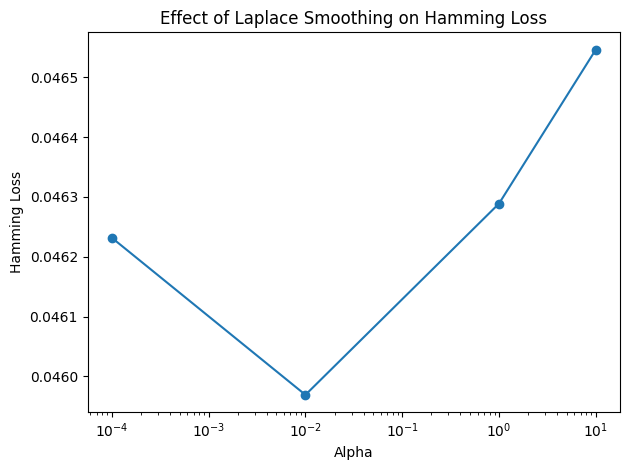

                   hep-ex  log-score: -404.64
                   hep-ph  log-score: -428.55
                  nucl-ex  log-score: -455.16
                  nucl-th  log-score: -472.30
          physics.ins-det  log-score: -474.08


In [110]:
# --- ANALYSIS FOR REPORT ---
alphas = [0.0001, 0.01, 1.0, 10.0]
results = []

# TODO 16 (Analysis - Report): Alpha Smoothing Experiment
# Loop through the alpha list, re-initialize the model, 
# train it, and store the Hamming Loss for each version.
# Then, use plt.plot() to visualize the trend.
for alpha in alphas:                                                                                   
    m = AdvancedBayesianClassifier(alpha=alpha)                                                      
    m.fit(X_train, y_train)                                                                            
    y_pred_alpha = m.predict(X_test)                                                                   
    hl = hamming_loss(y_test, y_pred_alpha)                                                            
    results.append(hl)                                                                                 
    print(f"alpha={alpha}: Hamming Loss={hl:.5f}") 
plt.plot(alphas, results, marker='o')                                                                  
plt.xscale('log')
plt.xlabel('Alpha')                                                                                    
plt.ylabel('Hamming Loss')                                                                           
plt.title('Effect of Laplace Smoothing on Hamming Loss')
plt.tight_layout()                                                                                     
plt.show()
# TODO 17 (Free Response - Report): Theoretical Question
# If a word in the test set never 
# appeared in the training set for a specific class, what happens 
# mathematically if alpha is set to exactly 0?

# 2. Probability Calibration
sample_idx = 42
# TODO 18 (Analysis - Report): Probability Calibration
# Access the raw log-probabilities for this sample. 
# Sort them and print the top 5 class names alongside their log-scores.
# Are the scores close together (high uncertainty) or far apart (high confidence)?
sample_scores = model.classes[sample_idx]                                                              
top5_idx = np.argsort(sample_scores)[::-1][:5]
for idx in top5_idx:                                                                                   
    print(f"{mlb.classes_[idx]:>25s}  log-score: {sample_scores[idx]:.2f}")   